# 04b — Predicción de resultado (contratado / no contratado) basada en prefijos

**Monitorización predictiva orientada a resultados** sobre el log de reclutamiento.
Se predice el resultado binario de contratación de cada candidatura en un **punto en el
tiempo**, es decir, para casos **aún no finalizados**.

**Metodología (bibliografía):**

* **Teinemaa et al. (2019)** — un *único clasificador* entrenado sobre *prefijos* con
  codificación de *agregación* (frecuencia de actividades) es la configuración más
  fiable; **AUC-ROC** es la métrica principal bajo desbalance de clases.
* **Weytjens & De Weerdt (2021, §5.5-5.6)** — *partición temporal estricta*: en
  entrenamiento solo se conservan los casos que **finalizan antes** del tiempo de
  separación; los casos aún en curso pasan al conjunto de test como sus **prefijos
  observados** (el escenario "predecir casos no finalizados en un punto en el tiempo").
* **Ceravolo et al. (2024)** — tratamiento del desbalance (remuestreo vs. coste).

> ⚠️ La partición 60/20/20 estricta **difiere** del 80/20 habitual en los *benchmarks*
> publicados; por tanto los valores absolutos **no son directamente comparables** con
> dichos *benchmarks*. El objetivo es una evaluación realista y sin fuga de información.

Toda la lógica vive en `src/outcome_prefix.py`; este cuaderno es un *driver* delgado.

## 0 · Configuración

In [1]:
import os, sys, warnings
os.environ.setdefault("PYTHON_GIL", "0")
warnings.filterwarnings("ignore", message="X does not have valid feature names")

# Ejecutar desde la raíz del worktree para que `import src...` funcione.
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
sys.path.insert(0, os.getcwd())

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from src import outcome_prefix as op

# ---- Parámetros del experimento ----
SEED         = op.SEED     # 42
GAP          = 3           # filtrado por saltos (Teinemaa gap filtering)
MAX_PREFIX   = 20          # longitud máxima de prefijo (cubre >95% de las trazas)
BIGRAM_TOPK  = 200         # nº de bigramas (directly-follows) más frecuentes
N_ITER       = 10          # iteraciones de búsqueda aleatoria (validación)
SEARCH_SUB   = 60000       # submuestreo del train solo para la búsqueda de hiperparám.
FAST_MODE    = False        # True: submuestra + rejilla reducida (verificación rápida)

NROWS  = 200000 if FAST_MODE else None
FIGDIR = "figs"
OUTDIR = "output"; os.makedirs(OUTDIR, exist_ok=True)
np.random.seed(SEED)
print("FAST_MODE =", FAST_MODE, "| NROWS =", NROWS)

FAST_MODE = False | NROWS = None


## 1 · Carga de datos

Se leen solo las columnas necesarias. Las columnas que codifican directamente el
resultado (`Rejected`, `Disposition Reason`, `All Stages...`) **nunca** se cargan como
predictoras (fuga de información). `Recruiting Agency` vacío = *sourcing* directo →
`"Direct"`.

In [2]:
events = op.load_event_log(nrows=NROWS)
print(f"Eventos: {len(events):,}  |  Casos: {events[op.CASE_COL].nunique():,}  "
      f"|  Actividades: {events[op.ACT_COL].nunique()}")
cases = op.build_case_table(events)
print(f"Tabla de casos: {cases.shape}  |  Tasa de contratación: {cases['y'].mean():.4%}")
cases.head()

Eventos: 1,123,421  |  Casos: 279,458  |  Actividades: 36


Tabla de casos: (279458, 9)  |  Tasa de contratación: 2.0132%


,Case_id,start,end,y,Recruiting Agency,Region,Country,Job Family,Job Family Group
0,000086ee80c8 - 10fb9be7d6ea,2024-10-17 15:21:25.626,2024-11-04 15:21:58.288,0,Direct,4,15,57,16
1,00009bcbfebb - 0b48a8d2135e,2025-12-09 11:17:47.514,2025-12-09 11:17:47.514,0,Direct,4,15,61,10
2,0000de8a0f78 - f2cdb518181b,2024-11-21 13:56:59.129,2024-11-21 13:56:59.129,0,Direct,4,15,21,17
3,000172b8c2d3 - 8444c6d11b1b,2025-08-19 08:53:49.132,2025-08-19 08:53:49.132,0,Direct,4,15,148,8
4,00017dc76e7e - 581689fd96b0,2023-08-25 11:20:03.055,2023-08-25 11:20:03.055,0,Direct,5,15,59,0


## 2 · Exploración

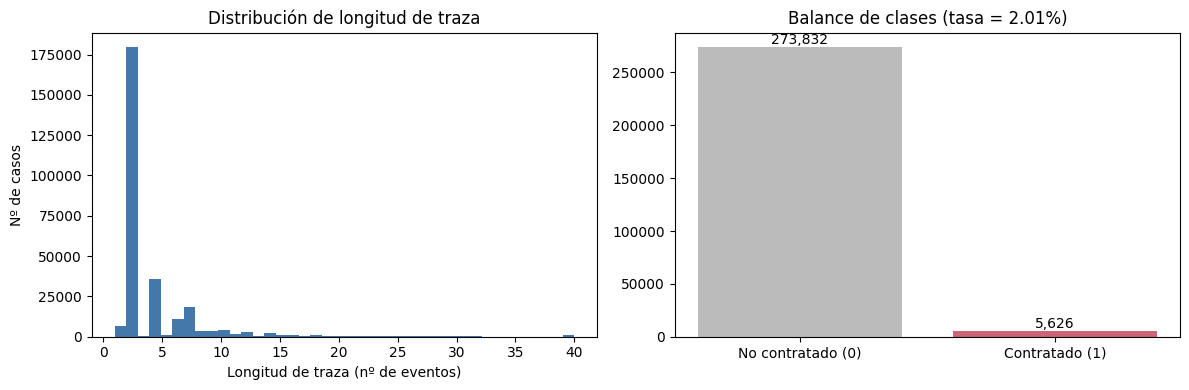

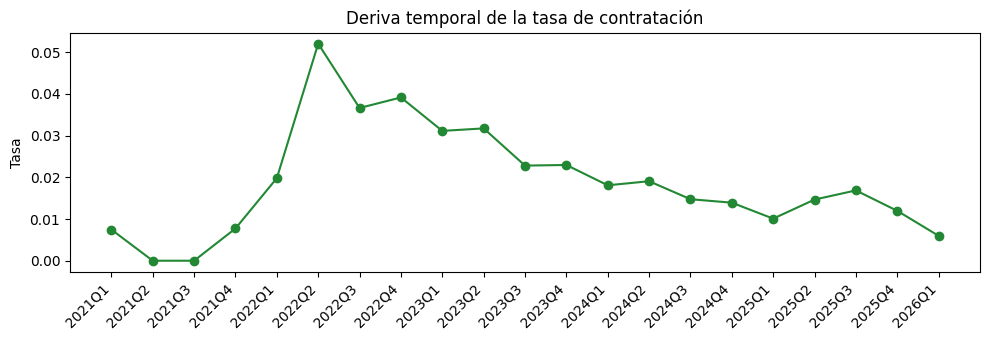

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
# Distribución de longitud de traza
tl = events.groupby(op.CASE_COL).size()
axes[0].hist(tl.clip(upper=40), bins=40, color="#4477AA")
axes[0].set_xlabel("Longitud de traza (nº de eventos)"); axes[0].set_ylabel("Nº de casos")
axes[0].set_title("Distribución de longitud de traza")
# Balance de clases
vc = cases["y"].value_counts().sort_index()
axes[1].bar(["No contratado (0)", "Contratado (1)"], vc.values, color=["#BBBBBB", "#CC6677"])
axes[1].set_title(f"Balance de clases (tasa = {cases['y'].mean():.2%})")
for i, v in enumerate(vc.values):
    axes[1].text(i, v, f"{v:,}", ha="center", va="bottom")
plt.tight_layout(); plt.show()

# Deriva temporal de la tasa de contratación (por trimestre de inicio)
cases["_q"] = cases["start"].dt.to_period("Q")
q = cases.groupby("_q")["y"].mean()
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(q.index.astype(str), q.values, "o-", color="#228833")
ax.set_title("Deriva temporal de la tasa de contratación"); ax.set_ylabel("Tasa")
plt.xticks(rotation=45, ha="right"); plt.tight_layout(); plt.show()

## 3 · Partición temporal estricta (60/20/20)

`train` = casos finalizados antes de `sep1`; `val` = casos que inician en `[sep1, sep2)` y
finalizan antes de `sep2`; `test` = casos que inician tras `sep2` **más** los *straddlers*
(en curso en `sep2`, observados solo hasta `sep2`).

In [4]:
split = op.temporal_split(cases)

# Verificación de ausencia de fuga: ningún caso de train/val solapa el periodo posterior.
c = split.cases
assert (c[c.split == "train"]["end"] < split.sep1).all(), "Fuga: train solapa el periodo de val"
assert (c[c.split == "val"]["end"] < split.sep2).all(), "Fuga: val solapa el periodo de test"
print("[OK] Partición temporal estricta verificada (sin solapamiento hacia periodos posteriores).")

Separation times: sep1=2024-09-12 02:28:12.977400064  sep2=2025-08-29 16:09:46.891200
  train: n= 162134  hired= 3928  hire_rate=2.4227%
  val  : n=  54686  hired=  683  hire_rate=1.2489%
  test : n=  57113  hired=  771  hire_rate=1.3500%
  test straddlers (running at sep2, observed as prefix): 1221
[OK] Partición temporal estricta verificada (sin solapamiento hacia periodos posteriores).


## 4 · Generación de prefijos y codificación

Prefijos por **saltos** (`gap`); los *straddlers* aportan un único prefijo = eventos
observados antes de `sep2`. Tres codificaciones de flujo de control (**booleana**,
**frecuencia** = agregación de Teinemaa, **bigramas** = pares *directly-follows*) más los
5 atributos estáticos de caso (codificación por etiquetas). Los vocabularios y
codificadores se ajustan **solo sobre train**.

In [5]:
data = op.build_prefix_dataset(events, split, gap=GAP, max_prefix=MAX_PREFIX)

# Ejemplo: matriz de una codificación y verificación de la máscara categórica de SMOTE-NC.
demo = op.build_features(data, "frequency", bigram_topk=BIGRAM_TOPK)
print(f"Dimensión de características (frecuencia): {demo.X['train'].shape[1]}")
_ = op.verify_smotenc_mask(demo)

Prefix generation (148.5s), gap=3, max_prefix=20:
  train:   406031 prefixes  hire_rate=7.2706%
  val  :   119659 prefixes  hire_rate=4.1008%
  test :   130478 prefixes  hire_rate=3.2335%


Dimensión de características (frecuencia): 39
  [SMOTE-NC] categorical mask verified: 5 cols ['Recruiting Agency_enc', 'Region_enc', 'Country_enc', 'Job Family_enc', 'Job Family Group_enc'] (agency @ [34])


## 5 · Tratamiento del desbalance y entrenamiento

Rejilla completa **3 codificaciones × 3 estrategias × 3 modelos = 27 configuraciones**.

* **Estrategias:** `none` (línea base), `smotenc` (SMOTE-NC solo sobre train, con la
  máscara categórica verificada programáticamente), `classweight`
  (`class_weight='balanced'` para RF; `scale_pos_weight = n_neg/n_pos` para XGB/LGBM,
  con aserción de que el valor llega al modelo).
* **Modelos:** Random Forest, XGBoost, LightGBM. Búsqueda aleatoria de hiperparámetros
  seleccionada **solo sobre validación**; el test no se toca hasta la evaluación final.

In [6]:
results, artifacts = op.run_grid(
    data, n_iter=N_ITER, fast=FAST_MODE, bigram_topk=BIGRAM_TOPK,
    search_subsample=SEARCH_SUB)
assert len(results) == 27 or FAST_MODE, "Se esperaban 27 configuraciones"
results_path = os.path.join(OUTDIR, "outcome_prefix_results.csv")
results.drop(columns=[c for c in results.columns if c.startswith("_")]).to_csv(results_path, index=False)
print("Guardado:", results_path, "| filas:", len(results))
results.head(10)


=== Encoding: boolean ===


    rf/none: best val AUC=0.9508 params={'n_estimators': 400, 'max_depth': 30, 'max_features': 0.3, 'min_samples_leaf': 20} scale_pos_weight=n/a


    xgb/none: best val AUC=0.9506 params={'n_estimators': 400, 'max_depth': 3, 'learning_rate': 0.1, 'subsample': 0.7, 'colsample_bytree': 1.0, 'min_child_weight': 1} scale_pos_weight=1.0


    lgbm/none: best val AUC=0.9514 params={'n_estimators': 300, 'num_leaves': 31, 'learning_rate': 0.03, 'subsample': 1.0, 'colsample_bytree': 0.7, 'min_child_samples': 50} scale_pos_weight=1.0


  [SMOTE-NC] categorical mask verified: 5 cols ['Recruiting Agency_enc', 'Region_enc', 'Country_enc', 'Job Family_enc', 'Job Family Group_enc'] (agency @ [34])


...

    rf/classweight: best val AUC=0.9413 params={'n_estimators': 400, 'max_depth': 30, 'max_features': 0.3, 'min_samples_leaf': 20} scale_pos_weight=n/a


    xgb/classweight: best val AUC=0.9439 params={'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.1, 'subsample': 1.0, 'colsample_bytree': 0.7, 'min_child_weight': 5} scale_pos_weight=12.753971748924494


    lgbm/classweight: best val AUC=0.9468 params={'n_estimators': 300, 'num_leaves': 31, 'learning_rate': 0.03, 'subsample': 1.0, 'colsample_bytree': 0.7, 'min_child_samples': 50} scale_pos_weight=12.753971748924494


Guardado: output\outcome_prefix_results.csv | filas: 27


,encoding,strategy,model,val_auc,scale_pos_weight,auc_roc,auc_pr,f1,balanced_acc,precision,recall,tn,fp,fn,tp
0,frequency,none,rf,0.952153,NaN,0.953962,0.707543,0.684897,0.784771,0.851356,0.572885,125837,422,1802,2417
1,boolean,none,rf,0.950843,NaN,0.952992,0.698097,0.662407,0.763045,0.887694,0.528324,125977,282,1990,2229
2,frequency,classweight,rf,0.948989,NaN,0.952249,0.694541,0.450016,0.876208,0.311184,0.812515,118671,7588,791,3428
3,frequency,none,xgb,0.951531,NaN,0.951521,0.708502,0.685414,0.784349,0.855067,0.571936,125850,409,1806,2413
4,frequency,none,lgbm,0.951649,NaN,0.951484,0.717356,0.692637,0.786194,0.870204,0.575255,125897,362,1792,2427
5,boolean,classweight,rf,0.948094,NaN,0.951221,0.689318,0.443970,0.875700,0.305331,0.813226,118453,7806,788,3431
6,frequency,classweight,lgbm,0.952066,12.753972,0.951082,0.708843,0.450454,0.880987,0.310062,0.823181,118531,7728,746,3473
7,boolean,classweight,lgbm,0.951574,12.753972,0.950700,0.706088,0.445583,0.880843,0.305302,0.824366,118345,7914,741,3478
8,boolean,none,lgbm,0.951443,NaN,0.950667,0.711970,0.688067,0.781904,0.876100,0.566485,125921,338,1829,2390
9,boolean,smotenc,rf,0.952312,NaN,0.948239,0.683818,0.440877,0.869732,0.304187,0.800664,118532,7727,841,3378


## 6 · Evaluación — figuras (etiquetas en español, PDF+PNG @300 dpi)

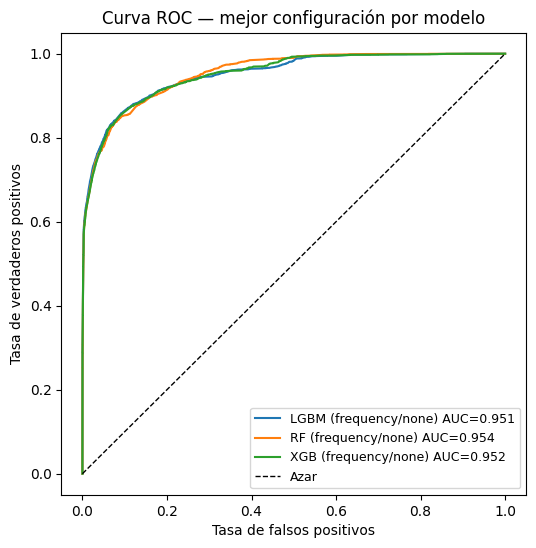

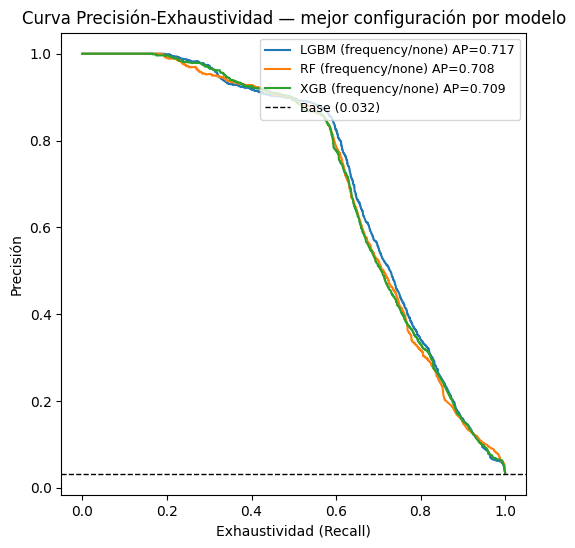

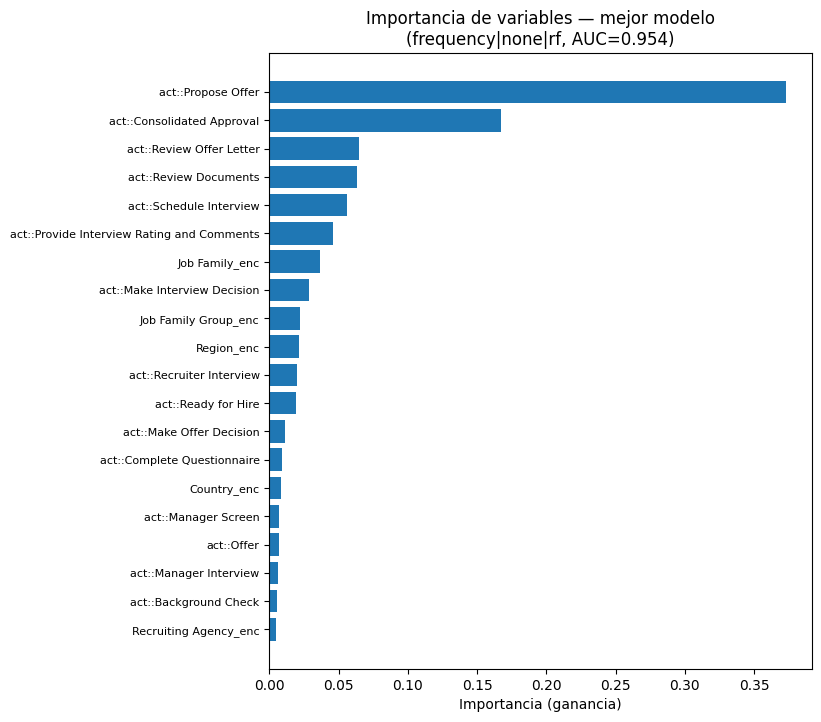

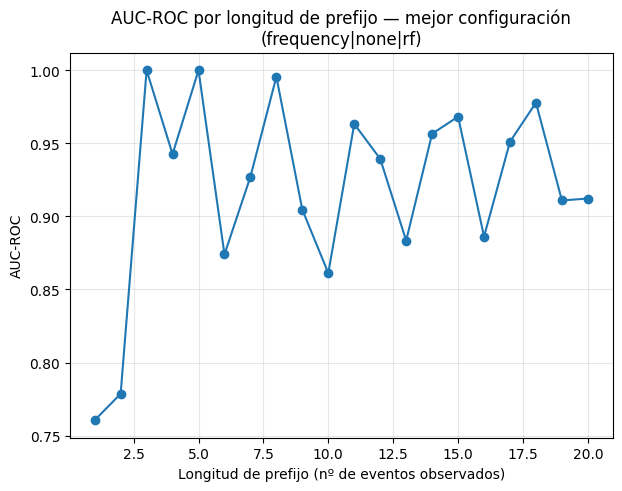

In [7]:
op.plot_roc(results, artifacts, figdir=FIGDIR); plt.show()
op.plot_pr(results, artifacts, figdir=FIGDIR); plt.show()
op.plot_feature_importance(results, artifacts, figdir=FIGDIR); plt.show()
op.plot_auc_vs_prefix(results, artifacts, figdir=FIGDIR); plt.show()

## 7 · Resumen

In [8]:
summary_path = op.write_summary(results, path="OUTCOME_PREFIX_SUMMARY.md")
best = results.iloc[0]
print(f"Mejor configuración: {best['encoding']} | {best['strategy']} | {best['model'].upper()}  "
      f"→ AUC-ROC = {best['auc_roc']:.4f}")

# ¿SMOTE-NC o ponderación de clases?
by = results.groupby("strategy")["auc_roc"].agg(["mean", "max"])
print(by)

Wrote OUTCOME_PREFIX_SUMMARY.md
Mejor configuración: frequency | none | RF  → AUC-ROC = 0.9540
                 mean       max
strategy                       
classweight  0.943921  0.952249
none         0.948079  0.953962
smotenc      0.939702  0.948239
